# Evaluation Results Visualization

JSON summaries under `results/<model>/<task_folder>/` (skips `log/`). Tier **easy / medium / hard** comes from the folder name (e.g. `inequality_en_easy`); accuracy is `summary.overall`.


In [64]:
import json
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List
import numpy as np
import matplotlib.font_manager as fm

# Korean font setup (macOS/Linux/Windows)
# Find available Korean fonts
korean_fonts = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'NanumBarunGothic', 'Malgun Gothic', 'Noto Sans CJK KR']
available_font = None
font_list = [f.name for f in fm.fontManager.ttflist]

for font in korean_fonts:
    if font in font_list:
        available_font = font
        break

if available_font:
    plt.rcParams['font.family'] = available_font
    print(f"Korean font set: {available_font}")
else:
    # Fallback: try to find any Korean-supporting font
    korean_support_fonts = [f for f in font_list if any(k in f for k in ['Apple', 'Nanum', 'Gothic', 'Malgun'])]
    if korean_support_fonts:
        # Prefer AppleGothic or NanumGothic
        preferred = [f for f in korean_support_fonts if 'AppleGothic' in f or 'NanumGothic' in f]
        if preferred:
            plt.rcParams['font.family'] = preferred[0]
            print(f"Korean font set (fallback): {preferred[0]}")
        else:
            plt.rcParams['font.family'] = korean_support_fonts[0]
            print(f"Korean font set (fallback): {korean_support_fonts[0]}")
    else:
        plt.rcParams['font.family'] = 'DejaVu Sans'
        print("Warning: No Korean font found. Using default font (Korean may not display correctly)")

# Prevent minus sign from breaking
plt.rcParams['axes.unicode_minus'] = False

sns.set_style("whitegrid")
sns.set_palette("husl")


def _repo_root() -> Path:
    """Resolve repo root so paths work regardless of Jupyter cwd."""
    start = Path.cwd().resolve()
    for p in [start, *start.parents]:
        if (p / "evaluation").is_dir() and (p / "results").is_dir():
            return p
    raise FileNotFoundError(
        "logical-puzzles repo root not found (expected evaluation/ and results/). "
        f"cwd={start}"
    )


# Results: single model run folder (task subdirs only; log/ is excluded in loader)
RESULTS_DIR = _repo_root() / "results" / "gemini_gemini-3-flash-preview_en"

print("Libraries loaded successfully")

Korean font set: AppleGothic
Libraries loaded successfully


## Data Loading Function

In [65]:
def load_all_results(results_dir: Path) -> pd.DataFrame:
    """One row per result folder; accuracy from summary.overall."""
    data = []
    model_name = results_dir.name

    for task_dir in sorted(results_dir.iterdir()):
        if not task_dir.is_dir() or task_dir.name == "log":
            continue
        json_files = sorted(task_dir.glob("*.json"))
        if not json_files:
            continue
        json_file = json_files[-1]
        try:
            with open(json_file, "r", encoding="utf-8") as f:
                result = json.load(f)
            metadata = result.get("metadata", {})
            overall = result.get("summary", {}).get("overall", {})
            data.append({
                "model": model_name,
                "task": task_dir.name,
                "timestamp": metadata.get("timestamp", ""),
                "total_puzzles": metadata.get("total_puzzles", 0),
                "accuracy": overall.get("accuracy", 0),
                "correct_count": overall.get("correct_count", 0),
                "total_count": overall.get("total_count", 0),
                "avg_latency_ms": overall.get("avg_latency_ms", 0),
            })
        except Exception as e:
            print(f"Error loading {json_file}: {e}")
    return pd.DataFrame(data)


## Load and Check Data

In [66]:
import re

_TASK_TIER_SUFFIX = re.compile(r"_(easy|medium|hard)$")


def parse_task_folder(task: str) -> tuple[str, str | None]:
    m = _TASK_TIER_SUFFIX.search(task)
    if not m:
        return task, None
    return task[: m.start()], m.group(1)


df = load_all_results(RESULTS_DIR)
df_overall = df.copy()

tier_rows = []
skipped = []
for _, row in df_overall.iterrows():
    base_task, tier = parse_task_folder(row["task"])
    if tier is None:
        skipped.append(row["task"])
        continue
    tier_rows.append({**row.to_dict(), "base_task": base_task, "difficulty": tier})

df_by_difficulty = pd.DataFrame(tier_rows)

print(f"Loaded {len(df_overall)} result folders")
print(f"Tasks: {sorted(df_overall['task'].unique())}")
print(f"Tiers (from folder name): {sorted(df_by_difficulty['difficulty'].unique())}")
if skipped:
    print(f"Skipped (no _easy/_medium/_hard suffix): {skipped}")
print(f"Plot rows: {len(df_by_difficulty)}")
if len(df_by_difficulty):
    print(df_by_difficulty[["task", "base_task", "difficulty", "accuracy"]].sort_values(["base_task", "difficulty"]).to_string(index=False))


Loaded 33 result folders
Tasks: ['array_formula_en_easy', 'array_formula_en_hard', 'array_formula_en_medium', 'causal_dag_en_easy', 'causal_dag_en_hard', 'causal_dag_en_medium', 'ferryman_en_easy', 'ferryman_en_hard', 'ferryman_en_medium', 'hanoi_en_easy', 'hanoi_en_hard', 'hanoi_en_medium', 'inequality_en_easy', 'inequality_en_hard', 'inequality_en_medium', 'logic_grid_en_easy', 'logic_grid_en_hard', 'logic_grid_en_medium', 'minesweeper_en_easy', 'minesweeper_en_hard', 'minesweeper_en_medium', 'number_baseball_en_easy', 'number_baseball_en_hard', 'number_baseball_en_medium', 'sat_puzzles_en_easy', 'sat_puzzles_en_hard', 'sat_puzzles_en_medium', 'sudoku_en_easy', 'sudoku_en_hard', 'sudoku_en_medium', 'yacht_dice_en_easy', 'yacht_dice_en_hard', 'yacht_dice_en_medium']
Tiers (from folder name): ['easy', 'hard', 'medium']
Plot rows: 33
                     task          base_task difficulty  accuracy
    array_formula_en_easy   array_formula_en       easy      0.74
    array_formula_en_ha

## 1. Overall Accuracy by Task

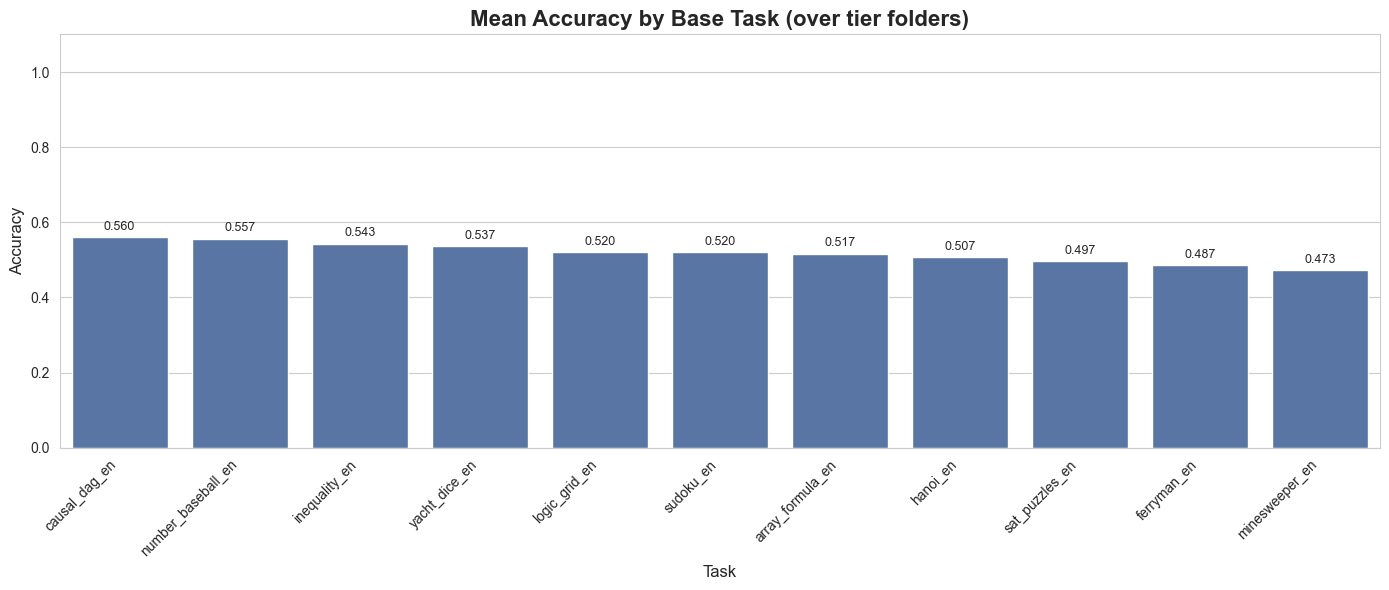

In [67]:
if len(df_by_difficulty) > 0:
    task_mean_df = df_by_difficulty.groupby("base_task", as_index=False)["accuracy"].mean()
else:
    task_mean_df = pd.DataFrame(columns=["base_task", "accuracy"])

plt.figure(figsize=(14, 6))
task_order = task_mean_df.sort_values("accuracy", ascending=False)["base_task"]
ax = sns.barplot(data=task_mean_df, x="base_task", y="accuracy", order=task_order, color="#4C72B0")
plt.title("Mean Accuracy by Base Task (over tier folders)", fontsize=16, fontweight="bold")
plt.xlabel("Task", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1.1)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", label_type="edge", padding=3, fontsize=9)
plt.tight_layout()
plt.show()


## 2. Accuracy by Task and Difficulty (Grouped Bar Chart)

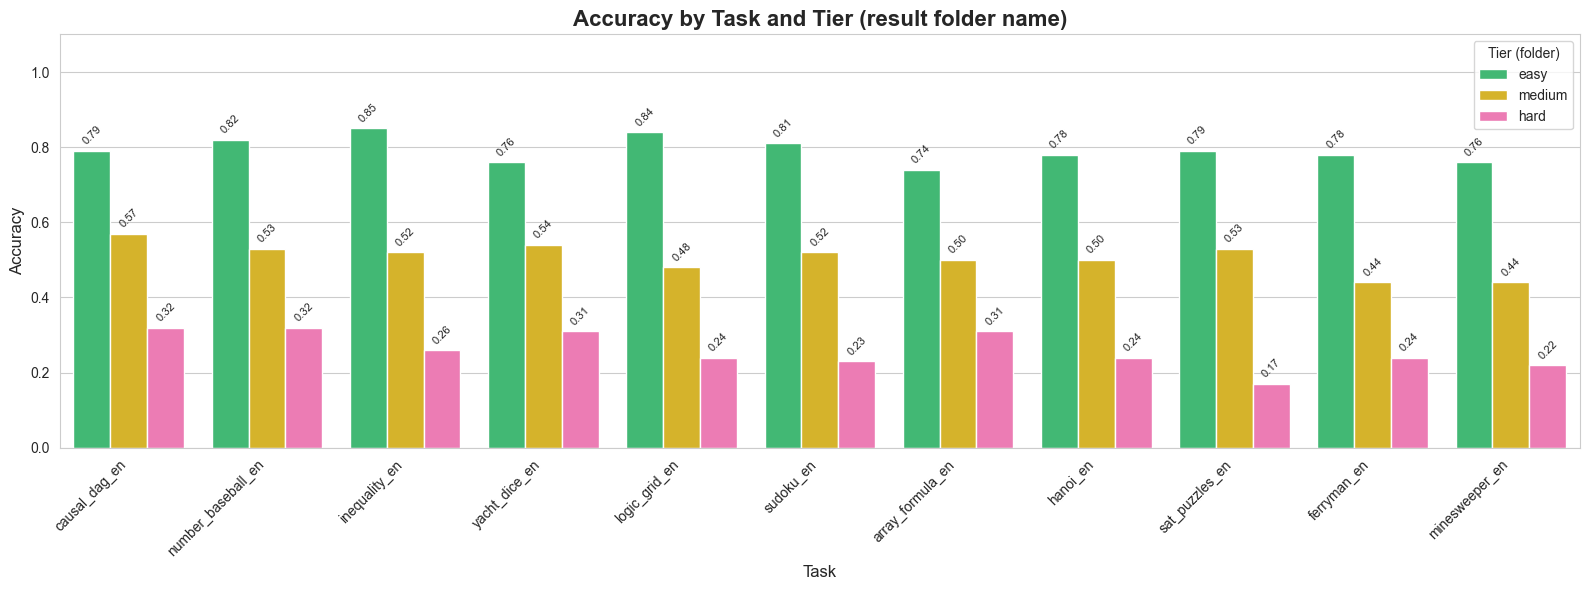

Legend tiers: ['easy', 'medium', 'hard']


In [68]:
DIFFICULTY_ORDER = ["easy", "medium", "hard"]
DIFFICULTY_COLORS = {"easy": "#2ecc71", "medium": "#f1c40f", "hard": "#ff69b4"}

# ── Language filter ────────────────────────────────────────────────────────────
# Set LANG_FILTER to "en", "ko", or None (= show all languages)
LANG_FILTER = None

if len(df_by_difficulty) == 0:
    print("No tier folders — run the load cell above first.")
else:
    tiers_present = [d for d in DIFFICULTY_ORDER if d in df_by_difficulty["difficulty"].values]
    if not tiers_present:
        print("No easy/medium/hard in folder names.")
    else:
        if LANG_FILTER is not None:
            filtered_df = df_by_difficulty[df_by_difficulty["base_task"].str.endswith(f"_{LANG_FILTER}")]
        else:
            filtered_df = df_by_difficulty
        plot_df = filtered_df[filtered_df["difficulty"].isin(tiers_present)].copy()
        task_order = (
            plot_df.groupby("base_task")["accuracy"].mean().sort_values(ascending=False).index
        )
        palette = [DIFFICULTY_COLORS[d] for d in tiers_present]

        fig, ax = plt.subplots(figsize=(16, 6))
        sns.barplot(
            data=plot_df,
            x="base_task",
            y="accuracy",
            hue="difficulty",
            hue_order=tiers_present,
            order=task_order,
            palette=palette,
            ax=ax,
        )
        ax.set_title("Accuracy by Task and Tier (result folder name)", fontsize=16, fontweight="bold")
        ax.set_xlabel("Task", fontsize=12)
        ax.set_ylabel("Accuracy", fontsize=12)
        ax.set_ylim(0, 1.1)
        ax.legend(title="Tier (folder)", loc="upper right")
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

        for container in ax.containers:
            ax.bar_label(
                container,
                labels=[f"{v:.2f}" for v in container.datavalues],
                label_type="edge",
                padding=3,
                fontsize=8,
                rotation=45,
            )
        plt.tight_layout()
        plt.show()
        print(f"Legend tiers: {tiers_present}")


## 3. Accuracy Heatmap by Task and Difficulty

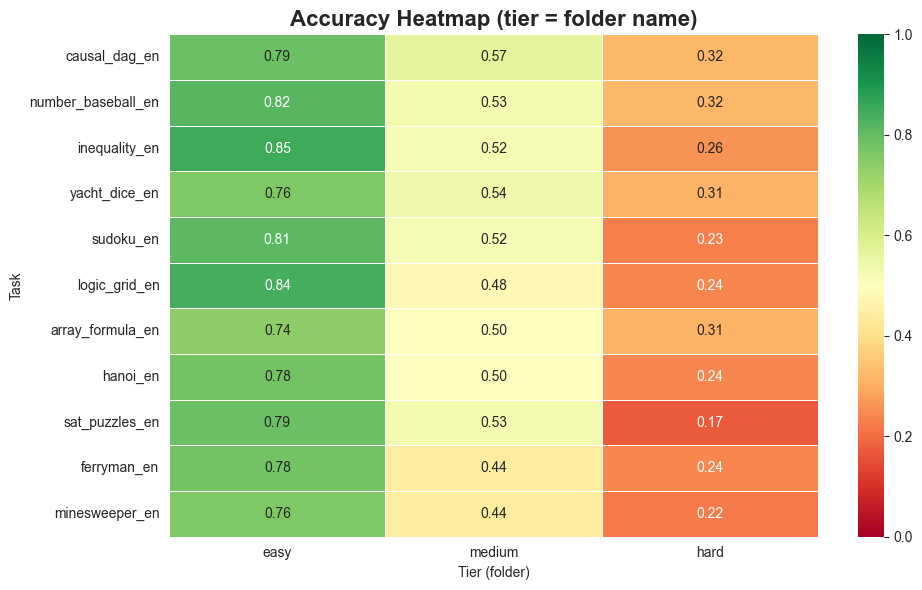

In [69]:
if len(df_by_difficulty) > 0:
    pivot_data = df_by_difficulty.pivot_table(
        index="base_task", columns="difficulty", values="accuracy", aggfunc="first"
    )
    col_order = [c for c in ["easy", "medium", "hard"] if c in pivot_data.columns]
    pivot_data = pivot_data[col_order]
    row_order = pivot_data.mean(axis=1).sort_values(ascending=False).index
    pivot_data = pivot_data.reindex(row_order)

    plt.figure(figsize=(10, max(6, len(pivot_data) * 0.5)))
    sns.heatmap(pivot_data, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1, linewidths=0.5)
    plt.title("Accuracy Heatmap (tier = folder name)", fontsize=16, fontweight="bold")
    plt.xlabel("Tier (folder)")
    plt.ylabel("Task")
    plt.tight_layout()
    plt.show()


## 4. Average Latency by Task

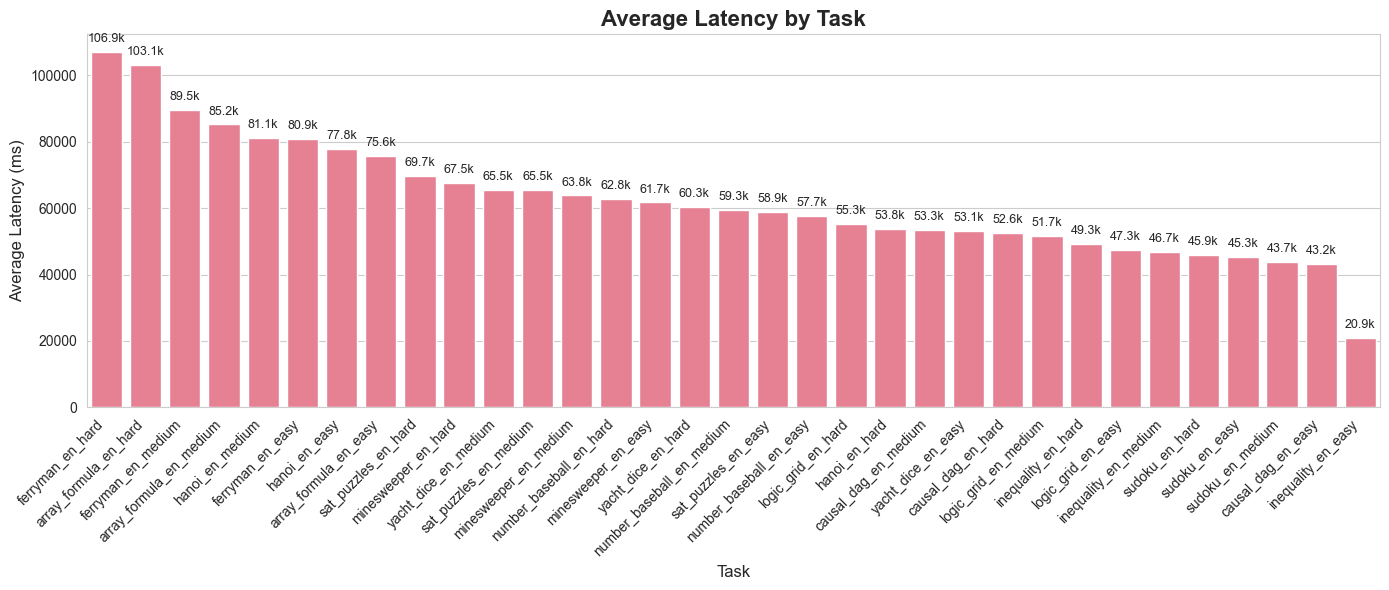

In [70]:
# Average latency by task
plt.figure(figsize=(14, 6))
task_order = df_overall.groupby('task')['avg_latency_ms'].mean().sort_values(ascending=False).index
ax = sns.barplot(data=df_overall, x='task', y='avg_latency_ms', order=task_order)
plt.title('Average Latency by Task', fontsize=16, fontweight='bold')
plt.xlabel('Task', fontsize=12)
plt.ylabel('Average Latency (ms)', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Add value labels on bars (format as thousands with 'k' suffix for readability)
for container in ax.containers:
    labels = []
    for val in container.datavalues:
        if val >= 1000:
            labels.append(f'{val/1000:.1f}k')
        else:
            labels.append(f'{val:.0f}')
    # Use 'edge' with top padding to place labels above bars
    ax.bar_label(container, labels=labels, label_type='edge', padding=5, fontsize=9, rotation=0)

plt.tight_layout()
plt.show()

## 5. Accuracy vs Latency Scatter Plot

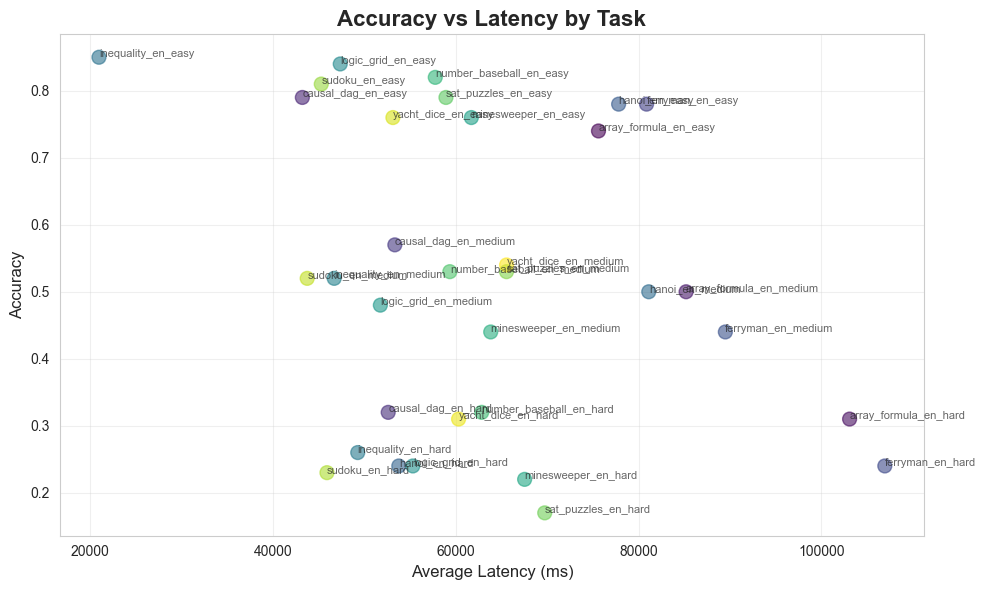

In [71]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_overall['avg_latency_ms'], df_overall['accuracy'], 
                     s=100, alpha=0.6, c=range(len(df_overall)), cmap='viridis')
for i, row in df_overall.iterrows():
    plt.annotate(row['task'], (row['avg_latency_ms'], row['accuracy']), 
                fontsize=8, alpha=0.7)
plt.xlabel('Average Latency (ms)', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy vs Latency by Task', fontsize=16, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## View detailed data

In [72]:
print("Per folder:")
print(df_overall[["task", "accuracy", "total_count"]].to_string(index=False))
if len(df_by_difficulty):
    print("\nBy tier:")
    print(df_by_difficulty[["base_task", "task", "difficulty", "accuracy"]].to_string(index=False))


Per folder:
                     task  accuracy  total_count
    array_formula_en_easy      0.74          100
    array_formula_en_hard      0.31          100
  array_formula_en_medium      0.50          100
       causal_dag_en_easy      0.79          100
       causal_dag_en_hard      0.32          100
     causal_dag_en_medium      0.57          100
         ferryman_en_easy      0.78          100
         ferryman_en_hard      0.24          100
       ferryman_en_medium      0.44          100
            hanoi_en_easy      0.78          100
            hanoi_en_hard      0.24          100
          hanoi_en_medium      0.50          100
       inequality_en_easy      0.85          100
       inequality_en_hard      0.26          100
     inequality_en_medium      0.52          100
       logic_grid_en_easy      0.84          100
       logic_grid_en_hard      0.24          100
     logic_grid_en_medium      0.48          100
      minesweeper_en_easy      0.76          100
      mi

## 6. 카테고리별 분석 (EN↔KO 전이) — 팀 공유용

4개 결과 폴더를 **task 카테고리**로 읽어 그래프 4종을 만들고 `results/plots/`에 PNG로 저장한다.

| 폴더 | 카테고리 |
|------|----------|
| `..._en`, `..._ko` | 직번역 (Language-neutral) |
| `..._lang` | 언어 특화 (Script-adapted): cipher, cryptarithmetic |
| `..._koko` | 한국어 전용 (Korean-exclusive): kinship, saju, jamo, time |

> `minesweeper_ko`는 평가가 끝나 `..._ko` 폴더에 생기면 **자동 포함**된다(별도 처리 불필요).

In [73]:
# ── Load the 4 category result folders ────────────────────────────────────────
CATEGORY_FOLDERS = {
    "gemini_gemini-3-flash-preview_en":   "Language-neutral",   # 직번역 EN
    "gemini_gemini-3-flash-preview_ko":   "Language-neutral",   # 직번역 KO (minesweeper_ko 포함 예정)
    "gemini_gemini-3-flash-preview_lang": "Script-adapted",     # 언어특화 EN+KO
    "gemini_gemini-3-flash-preview_koko": "Korean-exclusive",   # 한국어전용 KO
}

_DIFF_RE = re.compile(r"_(easy|medium|hard)$")
_LANG_RE = re.compile(r"_(en|ko)$")

def parse_full(folder: str):
    """'array_formula_en_easy' -> ('array_formula', 'en', 'easy')."""
    m = _DIFF_RE.search(folder)
    diff = m.group(1) if m else None
    stem = folder[: m.start()] if m else folder
    lm = _LANG_RE.search(stem)
    lang = lm.group(1) if lm else None
    base = stem[: lm.start()] if lm else stem
    return base, lang, diff

_root = _repo_root()
_frames = []
for _folder, _cat in CATEGORY_FOLDERS.items():
    _fdir = _root / "results" / _folder
    if not _fdir.is_dir():
        print(f"[skip] folder not found: {_folder}")
        continue
    _sub = load_all_results(_fdir)
    if _sub.empty:
        continue
    _sub["category"] = _cat
    _frames.append(_sub)

df_cat = pd.concat(_frames, ignore_index=True) if _frames else pd.DataFrame()
_parsed = df_cat["task"].apply(parse_full)
df_cat["base_task"]  = _parsed.apply(lambda t: t[0])
df_cat["lang"]       = _parsed.apply(lambda t: t[1])
df_cat["difficulty"] = _parsed.apply(lambda t: t[2])
df_cat = df_cat[df_cat["difficulty"].notna()].copy()

# ── Shared plot config ────────────────────────────────────────────────────────
DIFF_ORDER  = ["easy", "medium", "hard"]
DIFF_COLORS = {"easy": "#2ecc71", "medium": "#f1c40f", "hard": "#e74c3c"}
CAT_ORDER   = ["Language-neutral", "Script-adapted", "Korean-exclusive"]
CAT_COLORS  = {"Language-neutral": "#4C72B0", "Script-adapted": "#DD8452", "Korean-exclusive": "#55A868"}
TARGETS = {"easy": 0.75, "medium": 0.50, "hard": 0.25}
BANDS   = {"easy": (0.65, 0.85), "medium": (0.40, 0.60), "hard": (0.15, 0.35)}

OUT_DIR = _root / "results" / "plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Loaded {len(df_cat)} rows")
print(df_cat.groupby(["category", "lang"])["base_task"].nunique())
missing_ko = sorted(set(df_cat[df_cat.lang=="en"].base_task) - set(df_cat[df_cat.lang=="ko"].base_task))
if missing_ko:
    print(f"\n[note] EN-only (KO 미평가): {missing_ko}  → 산점도/격차 그래프에서 자동 제외, 평가되면 포함")
print(f"Output dir: {OUT_DIR}")


Loaded 90 rows
category          lang
Korean-exclusive  ko       4
Language-neutral  en      11
                  ko      11
Script-adapted    en       2
                  ko       2
Name: base_task, dtype: int64
Output dir: /Users/joon/Dev/AI/logical-puzzles/results/plots


### 6.1 난이도 보정 검증 — `calibration_overview.png`
카테고리별 subplot. 막대=task×난이도 정확도, 점선=Target(75/50/25), 음영=허용밴드.

saved: /Users/joon/Dev/AI/logical-puzzles/results/plots/calibration_overview.png


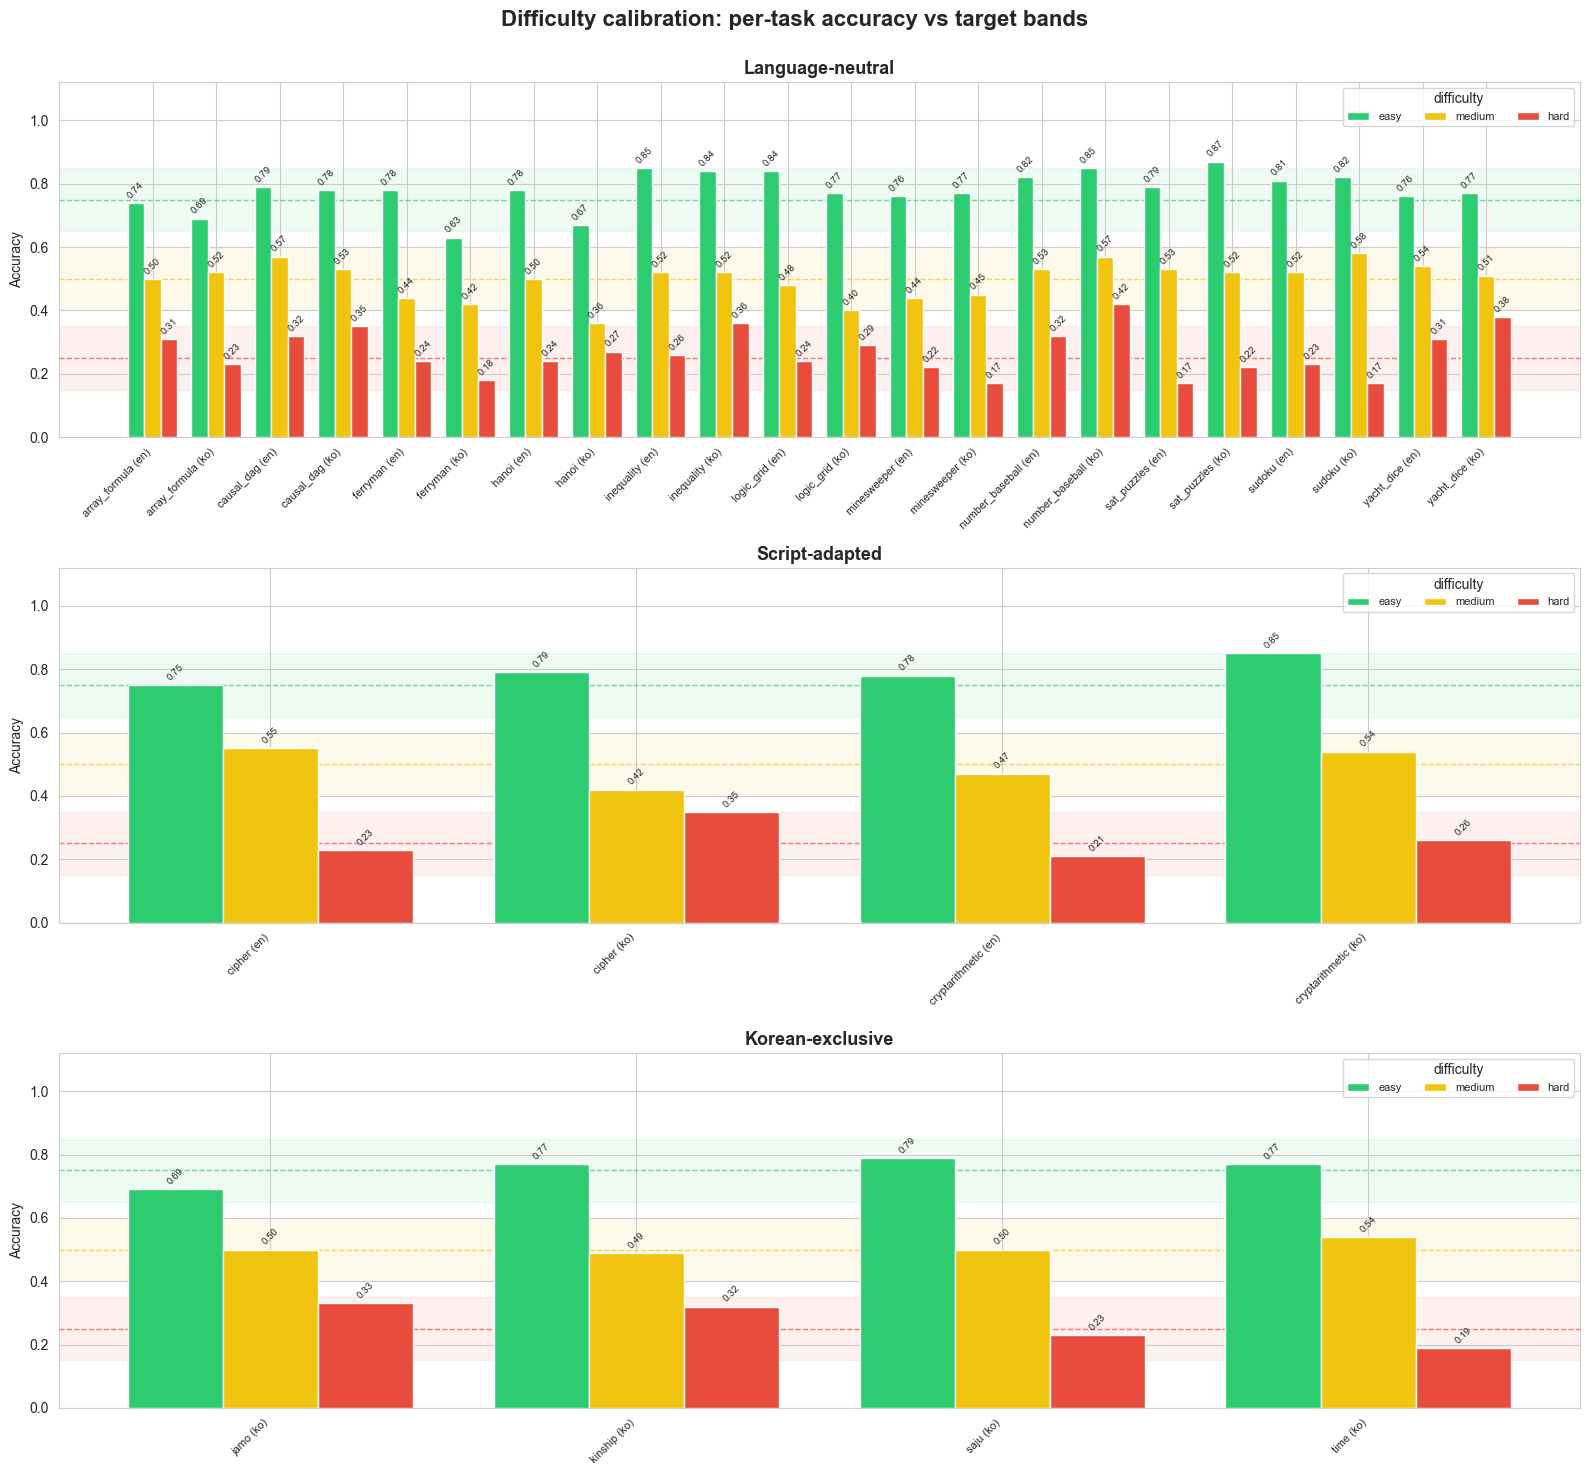

In [74]:
fig, axes = plt.subplots(len(CAT_ORDER), 1, figsize=(16, 15))
for ax, cat in zip(axes, CAT_ORDER):
    sub = df_cat[df_cat["category"] == cat].copy()
    if sub.empty:
        ax.set_visible(False)
        continue
    sub["xkey"] = sub["base_task"] + " (" + sub["lang"].fillna("?") + ")"
    xkeys = sorted(sub["xkey"].unique())
    x = np.arange(len(xkeys))
    width = 0.26
    for d in DIFF_ORDER:                       # target bands + lines
        lo, hi = BANDS[d]
        ax.axhspan(lo, hi, color=DIFF_COLORS[d], alpha=0.08, zorder=0)
        ax.axhline(TARGETS[d], color=DIFF_COLORS[d], ls="--", lw=1, alpha=0.7, zorder=1)
    for di, d in enumerate(DIFF_ORDER):
        vals = [sub[(sub.xkey == k) & (sub.difficulty == d)]["accuracy"].mean() for k in xkeys]
        b = ax.bar(x + (di - 1) * width, vals, width, label=d,
                   color=DIFF_COLORS[d], edgecolor="white", zorder=3)
        ax.bar_label(b, labels=[f"{v:.2f}" if pd.notna(v) else "" for v in vals],
                     fontsize=7, rotation=45, padding=2)
    ax.set_xticks(x)
    ax.set_xticklabels(xkeys, rotation=45, ha="right", fontsize=8)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel("Accuracy")
    ax.set_title(cat, fontsize=13, fontweight="bold")
    ax.legend(title="difficulty", loc="upper right", fontsize=8, ncol=3)
fig.suptitle("Difficulty calibration: per-task accuracy vs target bands", fontsize=16, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig(OUT_DIR / "calibration_overview.png", dpi=150, bbox_inches="tight")
print("saved:", OUT_DIR / "calibration_overview.png")
plt.show()


### 6.2 EN↔KO 전이 산점도 — `en_ko_transfer_scatter.png`
대각선 y=x에 가까울수록 언어 전이가 잘 됨. EN/KO 둘 다 있는 task만(Korean-exclusive 제외).

saved: /Users/joon/Dev/AI/logical-puzzles/results/plots/en_ko_transfer_scatter.png


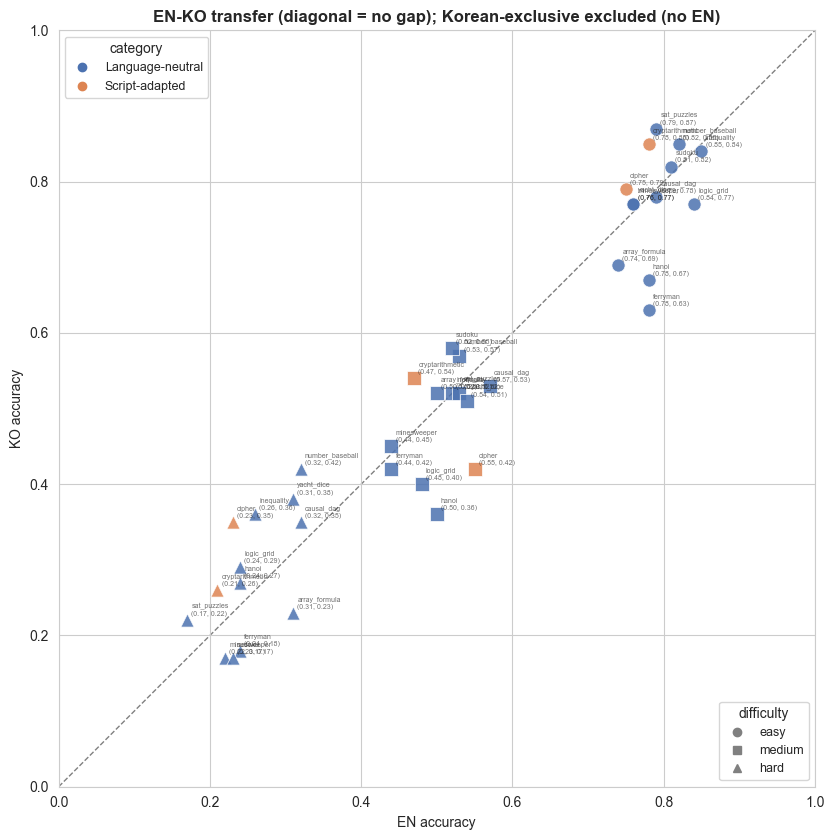

In [75]:
from matplotlib.lines import Line2D

pair = df_cat[df_cat.lang.isin(["en", "ko"])].pivot_table(
    index=["category", "base_task", "difficulty"], columns="lang",
    values="accuracy", aggfunc="first").reset_index()
pair = pair.dropna(subset=["en", "ko"])     # keep tasks evaluated in BOTH languages

MARKERS = {"easy": "o", "medium": "s", "hard": "^"}
fig, ax = plt.subplots(figsize=(8.5, 8.5))
ax.plot([0, 1], [0, 1], ls="--", color="gray", lw=1, zorder=0)
for cat in ["Language-neutral", "Script-adapted"]:
    for d in DIFF_ORDER:
        s = pair[(pair.category == cat) & (pair.difficulty == d)]
        ax.scatter(s["en"], s["ko"], c=CAT_COLORS[cat], marker=MARKERS[d],
                   s=90, alpha=0.85, edgecolor="white", linewidth=0.6, zorder=3)
for _, r in pair.iterrows():
    ax.annotate(f"{r['base_task']}\n({r['en']:.2f}, {r['ko']:.2f})",
                (r["en"], r["ko"]), fontsize=5, alpha=0.65,
                xytext=(3, 3), textcoords="offset points")
cat_handles  = [Line2D([0],[0], marker="o", ls="", color=CAT_COLORS[c], label=c)
                for c in ["Language-neutral", "Script-adapted"]]
diff_handles = [Line2D([0],[0], marker=MARKERS[d], ls="", color="gray", label=d) for d in DIFF_ORDER]
leg1 = ax.legend(handles=cat_handles, title="category", loc="upper left", fontsize=9)
ax.add_artist(leg1)
ax.legend(handles=diff_handles, title="difficulty", loc="lower right", fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
ax.set_xlabel("EN accuracy"); ax.set_ylabel("KO accuracy")
ax.set_title("EN-KO transfer (diagonal = no gap); Korean-exclusive excluded (no EN)", fontsize=12, fontweight="bold")
fig.tight_layout()
fig.savefig(OUT_DIR / "en_ko_transfer_scatter.png", dpi=150, bbox_inches="tight")
print("saved:", OUT_DIR / "en_ko_transfer_scatter.png")
plt.show()


### 6.3 카테고리 × 난이도 평균 — `category_summary.png`
그룹별 평균 정확도 + Target 라인/밴드. EN/KO 격차를 카테고리 수준에서 요약.

saved: /Users/joon/Dev/AI/logical-puzzles/results/plots/category_summary.png


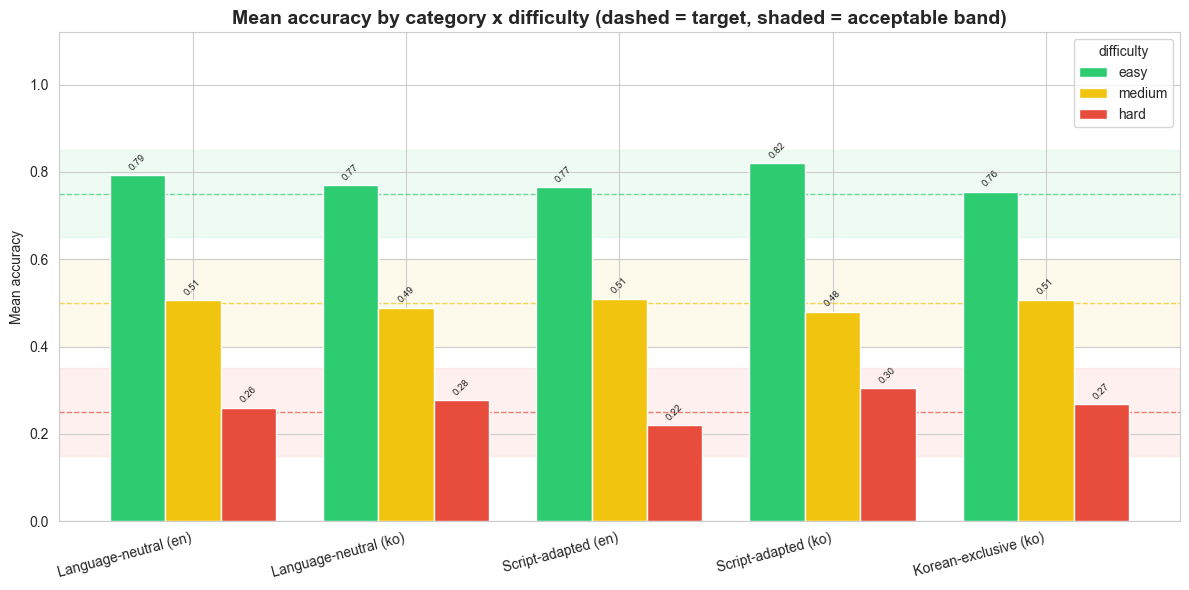

In [76]:
df_cat["group"] = df_cat["category"] + " (" + df_cat["lang"].fillna("ko") + ")"
GROUP_ORDER = ["Language-neutral (en)", "Language-neutral (ko)",
               "Script-adapted (en)", "Script-adapted (ko)", "Korean-exclusive (ko)"]
groups = [g for g in GROUP_ORDER if g in df_cat["group"].unique()]
x = np.arange(len(groups)); width = 0.26

fig, ax = plt.subplots(figsize=(12, 6))
for d in DIFF_ORDER:
    lo, hi = BANDS[d]
    ax.axhspan(lo, hi, color=DIFF_COLORS[d], alpha=0.08, zorder=0)
    ax.axhline(TARGETS[d], color=DIFF_COLORS[d], ls="--", lw=1, alpha=0.7, zorder=1)
for di, d in enumerate(DIFF_ORDER):
    vals = [df_cat[(df_cat.group == g) & (df_cat.difficulty == d)]["accuracy"].mean() for g in groups]
    bars = ax.bar(x + (di - 1) * width, vals, width, label=d,
                  color=DIFF_COLORS[d], edgecolor="white", zorder=3)
    ax.bar_label(bars, fmt="%.2f", fontsize=7, rotation=45, padding=2)
ax.set_xticks(x)
ax.set_xticklabels(groups, rotation=15, ha="right")
ax.set_ylim(0, 1.12); ax.set_ylabel("Mean accuracy")
ax.set_title("Mean accuracy by category x difficulty (dashed = target, shaded = acceptable band)", fontsize=14, fontweight="bold")
ax.legend(title="difficulty")
fig.tight_layout()
fig.savefig(OUT_DIR / "category_summary.png", dpi=150, bbox_inches="tight")
print("saved:", OUT_DIR / "category_summary.png")
plt.show()


### 6.4 EN−KO 격차 — `en_ko_gap.png`
Δ = KO − EN (난이도 평균). 양수=KO가 더 높음. 0에 가까울수록 언어 전이 양호.

saved: /Users/joon/Dev/AI/logical-puzzles/results/plots/en_ko_gap.png


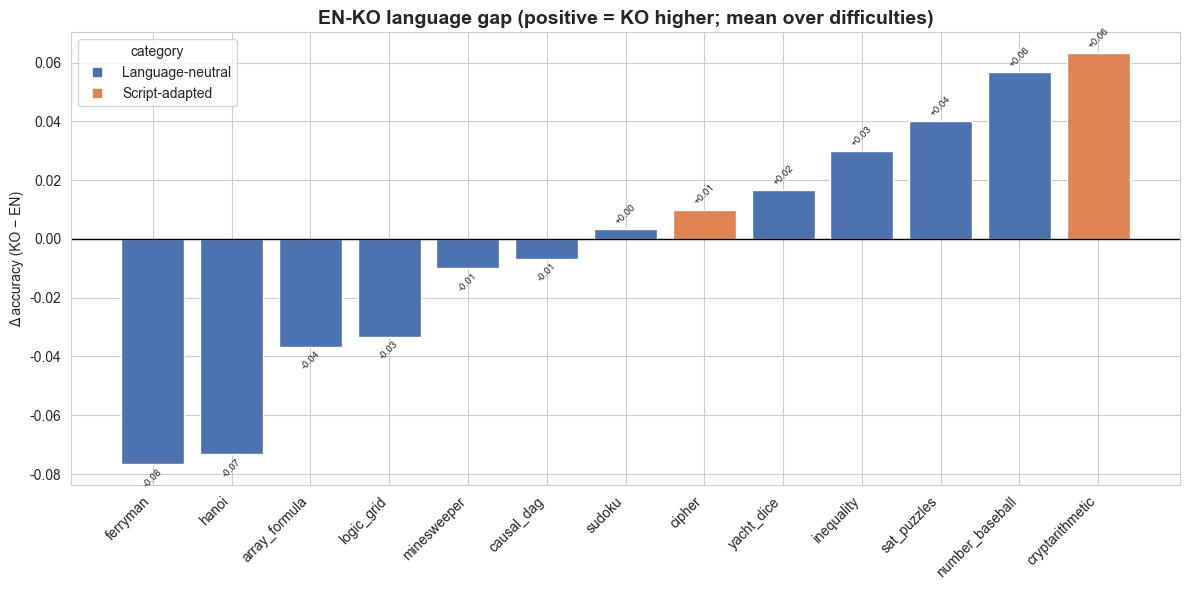

In [77]:
gap = pair.copy()
gap["delta"] = gap["ko"] - gap["en"]
gap_task = (gap.groupby(["category", "base_task"], as_index=False)["delta"].mean()
              .sort_values("delta"))

fig, ax = plt.subplots(figsize=(12, 6))
colors = [CAT_COLORS[c] for c in gap_task["category"]]
bars = ax.bar(np.arange(len(gap_task)), gap_task["delta"], color=colors, edgecolor="white")
ax.axhline(0, color="black", lw=1)
ax.bar_label(bars, labels=[f"{v:+.2f}" for v in gap_task["delta"]], fontsize=7, rotation=45, padding=2)
ax.set_xticks(np.arange(len(gap_task)))
ax.set_xticklabels(gap_task["base_task"], rotation=45, ha="right")
ax.set_ylabel("Δ accuracy (KO − EN)")
ax.set_title("EN-KO language gap (positive = KO higher; mean over difficulties)", fontsize=14, fontweight="bold")
cat_handles = [Line2D([0],[0], marker="s", ls="", color=CAT_COLORS[c], label=c)
               for c in ["Language-neutral", "Script-adapted"]]
ax.legend(handles=cat_handles, title="category")
fig.tight_layout()
fig.savefig(OUT_DIR / "en_ko_gap.png", dpi=150, bbox_inches="tight")
print("saved:", OUT_DIR / "en_ko_gap.png")
plt.show()


### 6.5 EN vs KO 직접 비교 — `en_ko_by_task.png`
EN/KO 둘 다 평가된 task(직번역 + 언어특화)만. **난이도별 subplot**에서 task마다 EN·KO 막대를
나란히 + 정확한 점수. (전체 패턴은 6.2 산점도, 격차 크기는 6.4 막대 참고.)

saved: /Users/joon/Dev/AI/logical-puzzles/results/plots/en_ko_by_task.png


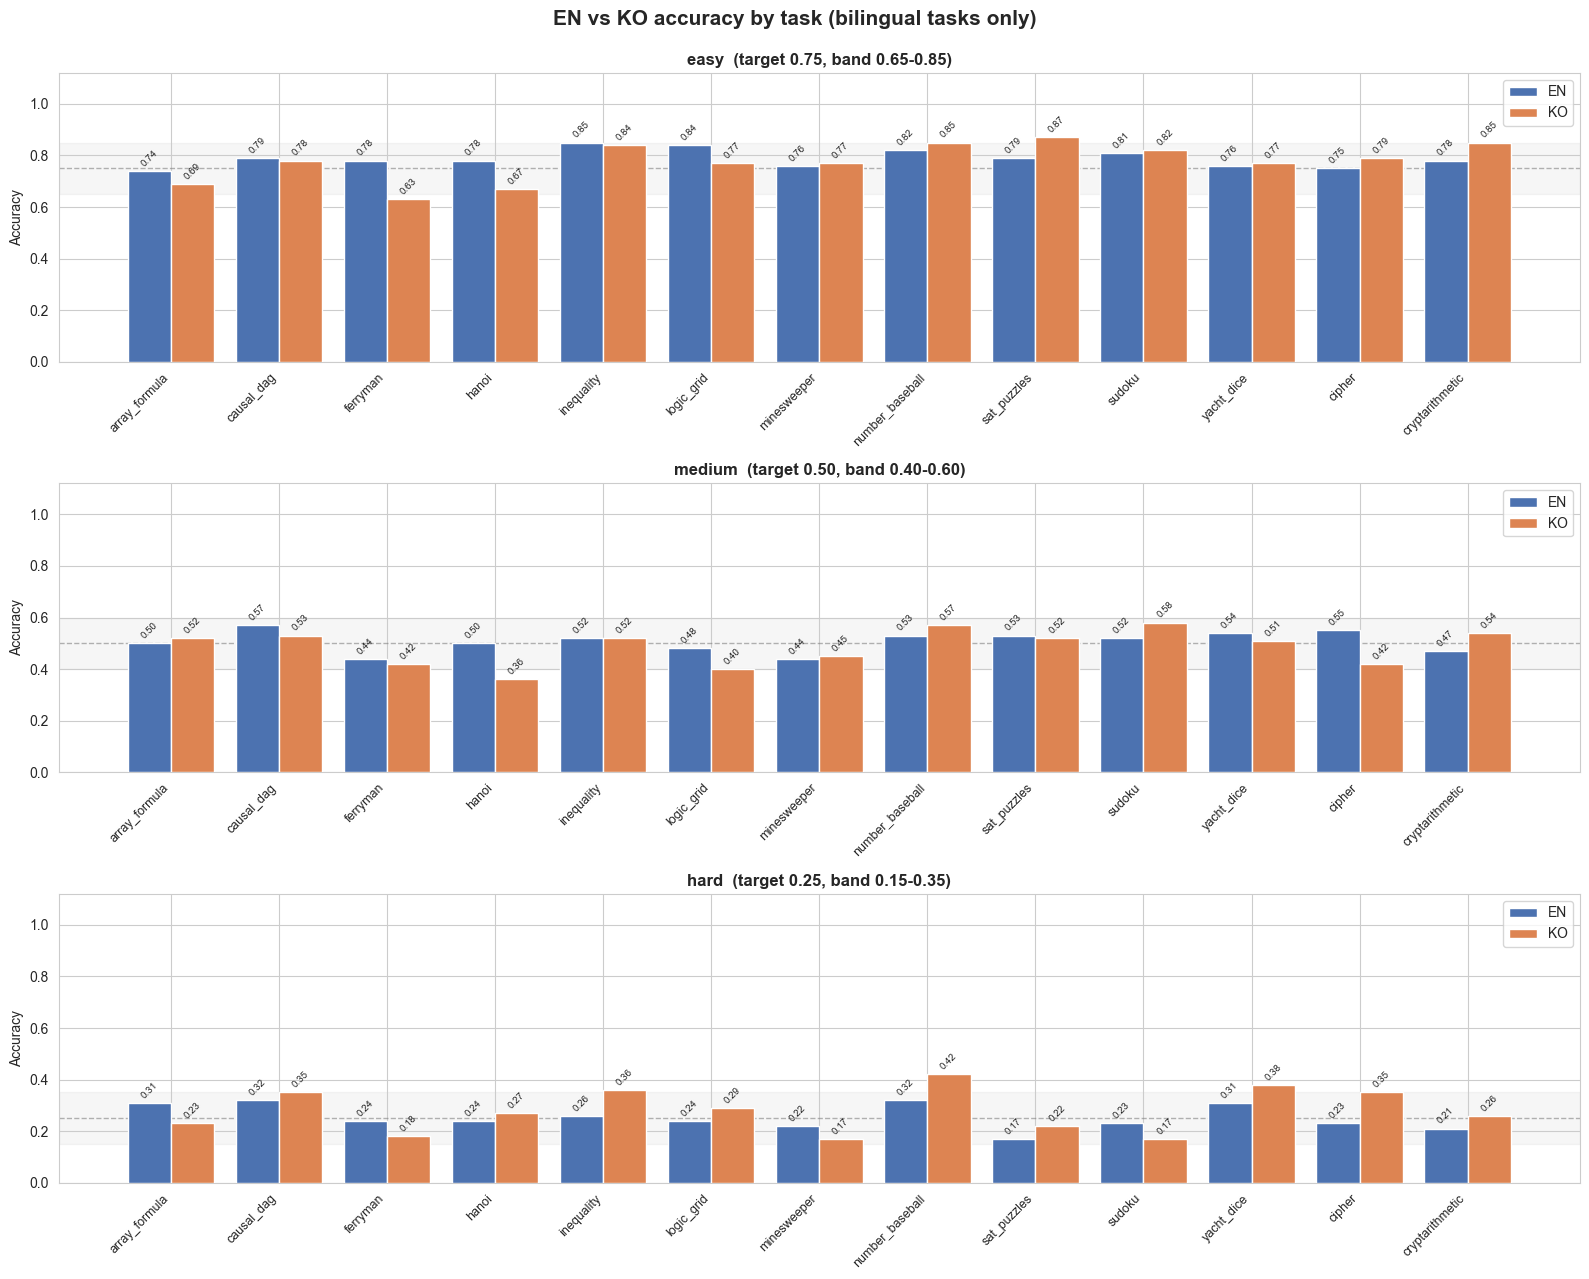

In [78]:
LANG_COLORS = {"en": "#4C72B0", "ko": "#DD8452"}

# tasks evaluated in BOTH languages, per difficulty
pair2 = df_cat[df_cat.lang.isin(["en", "ko"])].pivot_table(
    index=["category", "base_task", "difficulty"], columns="lang",
    values="accuracy", aggfunc="first").reset_index()
pair2 = pair2.dropna(subset=["en", "ko"])

# task order: category (Language-neutral -> Script-adapted) then name
_cat_rank = {c: i for i, c in enumerate(CAT_ORDER)}
task_order = (pair2[["category", "base_task"]].drop_duplicates()
              .assign(_r=lambda d: d.category.map(_cat_rank))
              .sort_values(["_r", "base_task"])["base_task"].tolist())

# mean over easy/medium/hard per task
mean_df = pair2.groupby("base_task")[["en", "ko"]].mean()
MEAN_TARGET = sum(TARGETS.values()) / len(TARGETS)   # (0.75+0.50+0.25)/3 = 0.50

panels = DIFF_ORDER + ["mean"]   # 마지막 패널 = 난이도 평균
fig, axes = plt.subplots(len(panels), 1, figsize=(16, 17))
for ax, d in zip(axes, panels):
    if d == "mean":
        tasks = [t for t in task_order if t in mean_df.index]
        en = [mean_df.loc[t, "en"] for t in tasks]
        ko = [mean_df.loc[t, "ko"] for t in tasks]
        ax.axhline(MEAN_TARGET, color="gray", ls="--", lw=1, alpha=0.6, zorder=1)
        title = f"mean over easy/medium/hard  (target {MEAN_TARGET:.2f})"
    else:
        sub = pair2[pair2.difficulty == d]
        tasks = [t for t in task_order if t in sub.base_task.values]
        en = [sub[sub.base_task == t]["en"].iloc[0] for t in tasks]
        ko = [sub[sub.base_task == t]["ko"].iloc[0] for t in tasks]
        lo, hi = BANDS[d]
        ax.axhspan(lo, hi, color="gray", alpha=0.07, zorder=0)
        ax.axhline(TARGETS[d], color="gray", ls="--", lw=1, alpha=0.6, zorder=1)
        title = f"{d}  (target {TARGETS[d]:.2f}, band {lo:.2f}-{hi:.2f})"
    x = np.arange(len(tasks)); w = 0.4
    b1 = ax.bar(x - w/2, en, w, label="EN", color=LANG_COLORS["en"], edgecolor="white", zorder=3)
    b2 = ax.bar(x + w/2, ko, w, label="KO", color=LANG_COLORS["ko"], edgecolor="white", zorder=3)
    ax.bar_label(b1, fmt="%.2f", fontsize=7, rotation=45, padding=2)
    ax.bar_label(b2, fmt="%.2f", fontsize=7, rotation=45, padding=2)
    ax.set_xticks(x)
    ax.set_xticklabels(tasks, rotation=45, ha="right", fontsize=9)
    ax.set_ylim(0, 1.12); ax.set_ylabel("Accuracy")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(loc="upper right")
fig.suptitle("EN vs KO accuracy by task (bilingual tasks only)", fontsize=15, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.99])
fig.savefig(OUT_DIR / "en_ko_by_task.png", dpi=150, bbox_inches="tight")
print("saved:", OUT_DIR / "en_ko_by_task.png")
plt.show()


### 6.6 EN vs KO 덤벨 차트 — `en_ko_dumbbell.png`
task마다 EN·KO 점을 선으로 연결(난이도별 subplot). 선 색 = 방향(초록=KO 높음, 빨강=KO 낮음),
양 끝에 정확한 점수. 격차 방향·크기와 절대 점수를 한 번에 보기 좋다.

saved: /Users/joon/Dev/AI/logical-puzzles/results/plots/en_ko_dumbbell.png


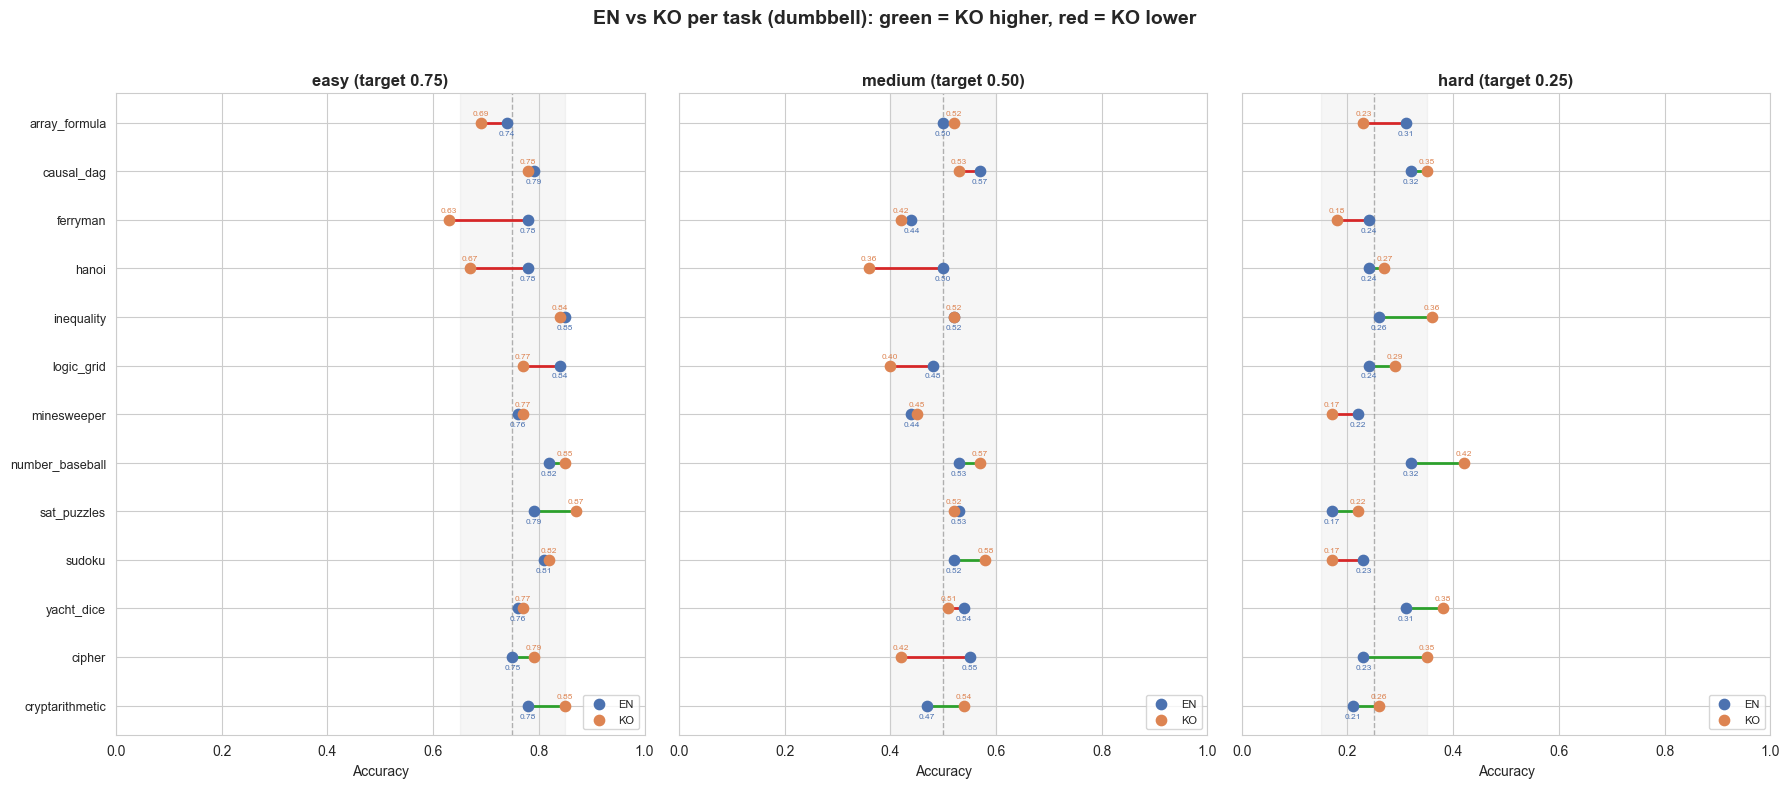

In [79]:
LANG_COLORS = {"en": "#4C72B0", "ko": "#DD8452"}
UP_C, DOWN_C = "#2ca02c", "#d62728"   # KO higher / KO lower

pair2 = df_cat[df_cat.lang.isin(["en", "ko"])].pivot_table(
    index=["category", "base_task", "difficulty"], columns="lang",
    values="accuracy", aggfunc="first").reset_index().dropna(subset=["en", "ko"])

# task order: category, then name reversed so it reads top→bottom nicely on y-axis
_cat_rank = {c: i for i, c in enumerate(CAT_ORDER)}
task_order = (pair2[["category", "base_task"]].drop_duplicates()
              .assign(_r=lambda d: d.category.map(_cat_rank))
              .sort_values(["_r", "base_task"], ascending=[False, False])["base_task"].tolist())

fig, axes = plt.subplots(1, len(DIFF_ORDER), figsize=(18, 8), sharey=True)
for ax, d in zip(axes, DIFF_ORDER):
    sub = pair2[pair2.difficulty == d].set_index("base_task")
    tasks = [t for t in task_order if t in sub.index]
    y = np.arange(len(tasks))
    en = [sub.loc[t, "en"] for t in tasks]
    ko = [sub.loc[t, "ko"] for t in tasks]
    lo, hi = BANDS[d]
    ax.axvspan(lo, hi, color="gray", alpha=0.07, zorder=0)
    ax.axvline(TARGETS[d], color="gray", ls="--", lw=1, alpha=0.6, zorder=1)
    for yi, (e, k) in enumerate(zip(en, ko)):
        ax.plot([e, k], [yi, yi], color=(UP_C if k >= e else DOWN_C), lw=2, zorder=2)
        ax.annotate(f"{e:.2f}", (e, yi), fontsize=6, ha="center", va="top",
                    xytext=(0, -5), textcoords="offset points", color=LANG_COLORS["en"])
        ax.annotate(f"{k:.2f}", (k, yi), fontsize=6, ha="center", va="bottom",
                    xytext=(0, 5), textcoords="offset points", color=LANG_COLORS["ko"])
    ax.scatter(en, y, color=LANG_COLORS["en"], s=55, zorder=3, label="EN")
    ax.scatter(ko, y, color=LANG_COLORS["ko"], s=55, zorder=3, label="KO")
    ax.set_yticks(y); ax.set_yticklabels(tasks, fontsize=9)
    ax.set_xlim(0, 1); ax.set_xlabel("Accuracy")
    ax.set_title(f"{d} (target {TARGETS[d]:.2f})", fontsize=12, fontweight="bold")
    ax.legend(loc="lower right", fontsize=8)
fig.suptitle("EN vs KO per task (dumbbell): green = KO higher, red = KO lower",
             fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(OUT_DIR / "en_ko_dumbbell.png", dpi=150, bbox_inches="tight")
print("saved:", OUT_DIR / "en_ko_dumbbell.png")
plt.show()
